# Modelling

## Цель

На основе исторических данных построить модель, прогнозирующую количество гостей ресторана.

На этапе моделирования:

- используется временное разделение данных без перемешивания;
- строится наивный baseline;
- качество оценивается с помощью MAE и MAPE;
- обучаемые модели сравниваются с baseline на одном и том же отложенном периоде;
- отдельно контролируется отсутствие утечки информации из будущего.

Итоговая модель должна использоваться для прогноза количества гостей на следующие 7 дней.

In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error
)

from prophet import Prophet
from catboost import CatBoostRegressor

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from time import perf_counter

import holidays

In [56]:
daily = pd.read_csv(
    "../data/processed/daily.csv",
    parse_dates=["date"]
)

daily = daily.sort_values("date").reset_index(drop=True)
display(daily.head())

,date,guests,is_holiday,day_of_week,month,is_weekend,days_since_start,guests_lag_1,guests_lag_7,guests_lag_14,guests_lag_28,guests_mean_7,guests_mean_14,guests_mean_28
0,2022-01-29,24,0,5,1,1,28,20.0,20.0,18.0,25.0,20.714286,21.428571,21.285714
1,2022-01-30,25,0,6,1,1,29,24.0,24.0,23.0,24.0,21.285714,21.857143,21.250000
2,2022-01-31,24,0,0,1,0,30,25.0,25.0,27.0,22.0,21.428571,22.000000,21.285714
3,2022-02-01,16,0,1,2,0,31,24.0,18.0,22.0,25.0,21.285714,21.785714,21.357143
4,2022-02-02,21,0,2,2,0,32,16.0,23.0,22.0,21.0,21.000000,21.357143,21.035714


## Проверка данных

В данном ноутбуке полный EDA не повторяется. Исследование качества данных, пропусков, выбросов, сезонности и календарных эффектов выполнено в 01_eda.ipynb.

Здесь проверяется только корректность загрузки подготовленного дневного ряда перед моделированием.

In [57]:
FEATURED_COL = [
    'day_of_week',
    'month',
    'is_weekend',
    'is_holiday',
    'days_since_start',

    'guests_lag_1',
    'guests_lag_7',
    'guests_lag_14',
    'guests_lag_28',

    'guests_mean_7',
    'guests_mean_14',
    'guests_mean_28'
]

VALID_WEEKS = 6
TEST_WEEKS = 12
TARGET = 'guests'
RANDOM_SEED = 42

In [58]:
print('Размер:', daily.shape)
print(
    'Период:',
    daily['date'].min(),
    '—',
    daily['date'].max()
)

print('Пропусков в target:', daily[TARGET].isna().sum())

display(daily.head())

Размер: (702, 14)
Период: 2022-01-29 00:00:00 — 2023-12-31 00:00:00
Пропусков в target: 0


,date,guests,is_holiday,day_of_week,month,is_weekend,days_since_start,guests_lag_1,guests_lag_7,guests_lag_14,guests_lag_28,guests_mean_7,guests_mean_14,guests_mean_28
0,2022-01-29,24,0,5,1,1,28,20.0,20.0,18.0,25.0,20.714286,21.428571,21.285714
1,2022-01-30,25,0,6,1,1,29,24.0,24.0,23.0,24.0,21.285714,21.857143,21.250000
2,2022-01-31,24,0,0,1,0,30,25.0,25.0,27.0,22.0,21.428571,22.000000,21.285714
3,2022-02-01,16,0,1,2,0,31,24.0,18.0,22.0,25.0,21.285714,21.785714,21.357143
4,2022-02-02,21,0,2,2,0,32,16.0,23.0,22.0,21.0,21.000000,21.357143,21.035714


In [59]:
required_columns = FEATURED_COL + [TARGET]

df = daily.dropna(
    subset=required_columns
).copy()

df = df.reset_index(drop=True)

In [60]:
print('Дней для моделирования:', len(df))

print(f'Период моделирования: {df["date"].min()} - {df["date"].max()}')

Дней для моделирования: 702
Период моделирования: 2022-01-29 00:00:00 - 2023-12-31 00:00:00


In [61]:
max_date = df['date'].max()

valid_start = (
    max_date
    - pd.Timedelta(weeks=VALID_WEEKS)
)

test_start = (
    valid_start
    - pd.Timedelta(weeks=TEST_WEEKS)
)

In [62]:
train = df[
    df['date'] <= test_start
].copy()
print(f'Количество недель train: {len(train)/7:.0f}')
test = df[
    (df['date'] > test_start)
    & (df['date'] <= valid_start)
].copy()
print(f'Количество недель test: {len(test)/7:.0f}')
valid = df[
    df['date'] > valid_start
].copy()
print(f'Количество недель валидации: {len(valid)/7:.0f}')

Количество недель train: 82
Количество недель test: 12
Количество недель валидации: 6


# 7-day forecasting backtest

Итоговая оценка соответствует постановке задачи: в начале каждой недели модель использует только доступную историю и одним запуском формирует прогнозы на горизонты 1–7 дней.

Модели рассматриваются последовательно: наивный baseline -> Linear Regression -> Prophet -> Catboost. После завершения очередной недели её фактические значения становятся доступной историей для следующего запуска.


In [63]:
def weekly_backtest(initial_history, evaluation_data, forecast_function):
    if len(evaluation_data) % 7 != 0:
        raise ValueError('Период оценки должен состоять из полных недель')

    history = initial_history.copy()
    prediction_records = []
    timing_records = []

    for week_number, start in enumerate(
        range(0, len(evaluation_data), 7), start=1
    ):
        week = evaluation_data.iloc[start:start + 7].copy()
        predictions, timing = forecast_function(history, week['date'])
        predictions = np.asarray(predictions)

        if len(predictions) != 7:
            raise ValueError('Модель должна вернуть ровно 7 прогнозов')

        for horizon, (_, row), prediction in zip(
            range(1, 8), week.iterrows(), predictions
        ):
            prediction_records.append({
                'date': row['date'],
                'actual': row[TARGET],
                'prediction': prediction,
                'horizon': horizon,
            })

        timing_records.append({
            'week': week_number,
            'fit_time_sec': timing['fit_time_sec'],
            'inference_time_sec': timing['inference_time_sec'],
        })

        history = pd.concat([history, week], ignore_index=True)

    return pd.DataFrame(prediction_records), pd.DataFrame(timing_records)


def calculate_metrics(backtest):
    mae = mean_absolute_error(backtest['actual'], backtest['prediction'])
    mape = mean_absolute_percentage_error(
        backtest['actual'], backtest['prediction']
    ) * 100
    return mae, mape


## Наивный baseline

Baseline переносит посещаемость соответствующего дня предыдущей недели: prediction(t) = guests(t - 7).

Все семь значений lag_7 известны в момент начала прогнозируемой недели, поэтому такая оценка не содержит утечки.


In [64]:
def baseline_forecast_7_days(history, future_dates):
    inference_start = perf_counter()
    predictions = history[TARGET].tail(7).to_numpy(dtype=float)
    inference_time = perf_counter() - inference_start

    return predictions, {
        'fit_time_sec': 0.0,
        'inference_time_sec': inference_time,
    }

baseline_backtest, baseline_timing = weekly_backtest(
    initial_history=train,
    evaluation_data=test,
    forecast_function=baseline_forecast_7_days,
)
baseline_mae_7d, baseline_mape_7d = calculate_metrics(baseline_backtest)

print(f'Baseline 7-day MAE: {baseline_mae_7d:.2f}')
print(f'Baseline 7-day MAPE: {baseline_mape_7d:.2f}%')
print(f'Среднее время инференса недели: {baseline_timing["inference_time_sec"].mean():.6f} сек.')
display(baseline_backtest.head(7))


Baseline 7-day MAE: 4.62
Baseline 7-day MAPE: 23.61%
Среднее время инференса недели: 0.000216 сек.


,date,actual,prediction,horizon
0,2023-08-28,22,17.0,1
1,2023-08-29,30,34.0,2
2,2023-08-30,20,23.0,3
3,2023-08-31,22,21.0,4
4,2023-09-01,21,25.0,5
5,2023-09-02,19,23.0,6
6,2023-09-03,16,11.0,7


## Linear Regression

Линейная регрессия прогнозирует неделю рекурсивно. Для первого дня признаки строятся по фактической истории. После каждого шага прогноз добавляется во временную историю, и lag_1 вместе со скользящими средними для следующего дня пересчитываются уже с использованием предыдущих прогнозов.

Таким образом, фактические значения внутри прогнозируемой недели модели недоступны.

In [65]:
us_holidays = holidays.US(
    years=range(daily['date'].dt.year.min(), daily['date'].dt.year.max() + 2)
)
series_start = daily['date'].min()

def make_recursive_features(guest_history, forecast_date):
    values = guest_history[TARGET].to_numpy(dtype=float)
    forecast_date = pd.Timestamp(forecast_date)

    return {
        'day_of_week': forecast_date.dayofweek,
        'month': forecast_date.month,
        'is_weekend': int(forecast_date.dayofweek in [5, 6]),
        'is_holiday': int(forecast_date.date() in us_holidays),
        'days_since_start': (forecast_date - series_start).days,
        'guests_lag_1': values[-1],
        'guests_lag_7': values[-7],
        'guests_lag_14': values[-14],
        'guests_lag_28': values[-28],
        'guests_mean_7': values[-7:].mean(),
        'guests_mean_14': values[-14:].mean(),
        'guests_mean_28': values[-28:].mean(),
    }


def linear_forecast_7_days(history, future_dates):
    training_data = history.dropna(subset=FEATURED_COL + [TARGET])
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression()),
    ])

    fit_start = perf_counter()
    model.fit(training_data[FEATURED_COL], training_data[TARGET])
    fit_time = perf_counter() - fit_start

    recursive_history = history[['date', TARGET]].copy()
    predictions = []

    inference_start = perf_counter()
    for forecast_date in pd.to_datetime(future_dates):
        feature_row = pd.DataFrame(
            [make_recursive_features(recursive_history, forecast_date)],
            columns=FEATURED_COL,
        )
        prediction = float(model.predict(feature_row)[0])
        predictions.append(prediction)

        recursive_history = pd.concat(
            [
                recursive_history,
                pd.DataFrame({'date': [forecast_date], TARGET: [prediction]}),
            ],
            ignore_index=True,
        )
    inference_time = perf_counter() - inference_start

    return np.asarray(predictions), {
        'fit_time_sec': fit_time,
        'inference_time_sec': inference_time,
    }


In [66]:
linear_backtest, linear_timing = weekly_backtest(
    initial_history=train,
    evaluation_data=test,
    forecast_function=linear_forecast_7_days,
)
linear_mae_7d, linear_mape_7d = calculate_metrics(linear_backtest)

print('Недельных запусков Linear Regression:', len(linear_backtest) // 7)
print(f'Linear Regression 7-day MAE: {linear_mae_7d:.2f}')
print(f'Linear Regression 7-day MAPE: {linear_mape_7d:.2f}%')
print(f'Среднее время инференса недели: {linear_timing["inference_time_sec"].mean():.6f} сек.')
display(linear_backtest.head(14))


Недельных запусков Linear Regression: 12
Linear Regression 7-day MAE: 3.35
Linear Regression 7-day MAPE: 17.07%
Среднее время инференса недели: 0.019441 сек.


,date,actual,prediction,horizon
0,2023-08-28,22,20.053948,1
1,2023-08-29,30,20.455362,2
2,2023-08-30,20,19.854657,3
3,2023-08-31,22,20.473123,4
4,2023-09-01,21,20.523446,5
5,2023-09-02,19,19.739850,6
6,2023-09-03,16,19.741623,7
7,2023-09-04,21,20.232300,1
8,2023-09-05,27,21.511126,2
9,2023-09-06,19,20.884150,3


## Prophet

Prophet перед каждой прогнозируемой неделей заново обучается на доступной истории. В future передаются только семь будущих дат, без фактических значений guests.


In [67]:
def prophet_forecast_7_days(history, future_dates):
    train_prophet = (
        history[['date', TARGET]]
        .rename(columns={'date': 'ds', TARGET: 'y'})
        .dropna()
        .sort_values('ds')
        .reset_index(drop=True)
    )

    model = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=False,
        daily_seasonality=False,
    )

    fit_start = perf_counter()
    model.fit(train_prophet)
    fit_time = perf_counter() - fit_start

    future = pd.DataFrame({'ds': pd.to_datetime(future_dates).to_numpy()})

    inference_start = perf_counter()
    predictions = model.predict(future)['yhat'].to_numpy()
    inference_time = perf_counter() - inference_start

    return predictions, {
        'fit_time_sec': fit_time,
        'inference_time_sec': inference_time,
    }


In [68]:
prophet_backtest, prophet_timing = weekly_backtest(
    initial_history=train,
    evaluation_data=test,
    forecast_function=prophet_forecast_7_days,
)
prophet_mae_7d, prophet_mape_7d = calculate_metrics(prophet_backtest)

print('Недельных запусков Prophet:', len(prophet_backtest) // 7)
print(f'Prophet 7-day MAE: {prophet_mae_7d:.2f}')
print(f'Prophet 7-day MAPE: {prophet_mape_7d:.2f}%')
print(f'Среднее время инференса недели: {prophet_timing["inference_time_sec"].mean():.6f} сек.')
display(prophet_backtest.head(14))


13:54:44 - cmdstanpy - INFO - Chain [1] start processing
13:54:44 - cmdstanpy - INFO - Chain [1] done processing


13:54:44 - cmdstanpy - INFO - Chain [1] start processing
13:54:44 - cmdstanpy - INFO - Chain [1] done processing
13:54:44 - cmdstanpy - INFO - Chain [1] start processing
13:54:44 - cmdstanpy - INFO - Chain [1] done processing
13:54:44 - cmdstanpy - INFO - Chain [1] start processing
13:54:44 - cmdstanpy - INFO - Chain [1] done processing
13:54:45 - cmdstanpy - INFO - Chain [1] start processing
13:54:45 - cmdstanpy - INFO - Chain [1] done processing
13:54:45 - cmdstanpy - INFO - Chain [1] start processing
13:54:45 - cmdstanpy - INFO - Chain [1] done processing
13:54:45 - cmdstanpy - INFO - Chain [1] start processing
13:54:45 - cmdstanpy - INFO - Chain [1] done processing
13:54:45 - cmdstanpy - INFO - Chain [1] start processing
13:54:45 - cmdstanpy - INFO - Chain [1] done processing
13:54:45 - cmdstanpy - INFO - Chain [1] start processing
13:54:45 - cmdstanpy - INFO - Chain [1] done processing
13:54:45 - cmdstanpy - INFO - Chain [1] start processing
13:54:45 - cmdstanpy - INFO - Chain [1]

Недельных запусков Prophet: 12
Prophet 7-day MAE: 3.33
Prophet 7-day MAPE: 16.86%
Среднее время инференса недели: 0.037766 сек.


,date,actual,prediction,horizon
0,2023-08-28,22,20.907734,1
1,2023-08-29,30,20.456159,2
2,2023-08-30,20,20.455803,3
3,2023-08-31,22,20.906663,4
4,2023-09-01,21,21.174599,5
5,2023-09-02,19,21.039480,6
6,2023-09-03,16,20.605376,7
7,2023-09-04,21,20.926812,1
8,2023-09-05,27,20.577251,2
9,2023-09-06,19,20.456605,3


## CatBoost

CatBoost используется как нелинейная модель градиентного бустинга. Как и Linear Regression, он прогнозирует семь дней рекурсивно: после каждого шага предсказание добавляется во временную историю, а лаги и скользящие средние пересчитываются перед следующим шагом.

Фактические значения внутри прогнозируемой недели модели недоступны. Параметры и random_seed фиксируются для воспроизводимости.


In [69]:
def catboost_forecast_7_days(history, future_dates):
    training_data = history.dropna(subset=FEATURED_COL + [TARGET])

    model = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function='MAE',
        random_seed=RANDOM_SEED,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )

    fit_start = perf_counter()
    model.fit(training_data[FEATURED_COL], training_data[TARGET])
    fit_time = perf_counter() - fit_start

    recursive_history = history[['date', TARGET]].copy()
    predictions = []

    inference_start = perf_counter()
    for forecast_date in pd.to_datetime(future_dates):
        feature_row = pd.DataFrame(
            [make_recursive_features(recursive_history, forecast_date)],
            columns=FEATURED_COL,
        )
        prediction = float(model.predict(feature_row)[0])
        predictions.append(prediction)

        recursive_history = pd.concat(
            [
                recursive_history,
                pd.DataFrame({'date': [forecast_date], TARGET: [prediction]}),
            ],
            ignore_index=True,
        )
    inference_time = perf_counter() - inference_start

    return np.asarray(predictions), {
        'fit_time_sec': fit_time,
        'inference_time_sec': inference_time,
    }


In [70]:
catboost_backtest, catboost_timing = weekly_backtest(
    initial_history=train,
    evaluation_data=test,
    forecast_function=catboost_forecast_7_days,
)
catboost_mae_7d, catboost_mape_7d = calculate_metrics(catboost_backtest)

print('Недельных запусков CatBoost:', len(catboost_backtest) // 7)
print(f'CatBoost 7-day MAE: {catboost_mae_7d:.2f}')
print(f'CatBoost 7-day MAPE: {catboost_mape_7d:.2f}%')
print(f'Среднее время инференса недели: {catboost_timing["inference_time_sec"].mean():.6f} сек.')
display(catboost_backtest.head(14))


Недельных запусков CatBoost: 12
CatBoost 7-day MAE: 3.38
CatBoost 7-day MAPE: 17.22%
Среднее время инференса недели: 0.018654 сек.


,date,actual,prediction,horizon
0,2023-08-28,22,20.715183,1
1,2023-08-29,30,19.623455,2
2,2023-08-30,20,20.640086,3
3,2023-08-31,22,20.364663,4
4,2023-09-01,21,20.762451,5
5,2023-09-02,19,20.584306,6
6,2023-09-03,16,20.530439,7
7,2023-09-04,21,20.389488,1
8,2023-09-05,27,22.621177,2
9,2023-09-06,19,19.425968,3


## Сравнение моделей на test

In [77]:
# Rolling backtest внутри train:
# первые данные используются как история,
# последние 12 недель train — для оценки.
TRAIN_EVAL_WEEKS = 12
TRAIN_EVAL_DAYS = TRAIN_EVAL_WEEKS * 7

train_history = train.iloc[:-TRAIN_EVAL_DAYS].copy()
train_eval = train.iloc[-TRAIN_EVAL_DAYS:].copy()

baseline_train_backtest, baseline_train_timing = weekly_backtest(
    initial_history=train_history,
    evaluation_data=train_eval,
    forecast_function=baseline_forecast_7_days,
)

linear_train_backtest, linear_train_timing = weekly_backtest(
    initial_history=train_history,
    evaluation_data=train_eval,
    forecast_function=linear_forecast_7_days,
)

prophet_train_backtest, prophet_train_timing = weekly_backtest(
    initial_history=train_history,
    evaluation_data=train_eval,
    forecast_function=prophet_forecast_7_days,
)

catboost_train_backtest, catboost_train_timing = weekly_backtest(
    initial_history=train_history,
    evaluation_data=train_eval,
    forecast_function=catboost_forecast_7_days,
)

baseline_train_mae, baseline_train_mape = calculate_metrics(
    baseline_train_backtest
)
linear_train_mae, linear_train_mape = calculate_metrics(
    linear_train_backtest
)
prophet_train_mae, prophet_train_mape = calculate_metrics(
    prophet_train_backtest
)
catboost_train_mae, catboost_train_mape = calculate_metrics(
    catboost_train_backtest
)

13:59:41 - cmdstanpy - INFO - Chain [1] start processing
13:59:41 - cmdstanpy - INFO - Chain [1] done processing
13:59:41 - cmdstanpy - INFO - Chain [1] start processing
13:59:41 - cmdstanpy - INFO - Chain [1] done processing
13:59:41 - cmdstanpy - INFO - Chain [1] start processing
13:59:41 - cmdstanpy - INFO - Chain [1] done processing
13:59:41 - cmdstanpy - INFO - Chain [1] start processing
13:59:41 - cmdstanpy - INFO - Chain [1] done processing
13:59:41 - cmdstanpy - INFO - Chain [1] start processing
13:59:41 - cmdstanpy - INFO - Chain [1] done processing
13:59:41 - cmdstanpy - INFO - Chain [1] start processing
13:59:41 - cmdstanpy - INFO - Chain [1] done processing
13:59:41 - cmdstanpy - INFO - Chain [1] start processing
13:59:41 - cmdstanpy - INFO - Chain [1] done processing
13:59:41 - cmdstanpy - INFO - Chain [1] start processing
13:59:41 - cmdstanpy - INFO - Chain [1] done processing
13:59:41 - cmdstanpy - INFO - Chain [1] start processing
13:59:41 - cmdstanpy - INFO - Chain [1]

In [81]:
results_7d = pd.DataFrame({
    'model': [
        'Baseline',
        'Linear Regression',
        'Prophet',
        'CatBoost',
    ],

    'train_MAE': [
        baseline_train_mae,
        linear_train_mae,
        prophet_train_mae,
        catboost_train_mae,
    ],

    'test_MAE': [
        baseline_mae_7d,
        linear_mae_7d,
        prophet_mae_7d,
        catboost_mae_7d,
    ],

    'train_MAPE': [
        baseline_train_mape,
        linear_train_mape,
        prophet_train_mape,
        catboost_train_mape,
    ],

    'test_MAPE': [
        baseline_mape_7d,
        linear_mape_7d,
        prophet_mape_7d,
        catboost_mape_7d,
    ]
})

display(results_7d.style.format({
    'train_MAE': '{:.3f}',
    'test_MAE': '{:.3f}',
    'train_MAPE': '{:.2f}%',
    'test_MAPE': '{:.2f}%'
}))

,model,train_MAE,test_MAE,train_MAPE,test_MAPE
0,Baseline,4.321,4.619,22.32%,23.61%
1,Linear Regression,3.546,3.351,19.23%,17.07%
2,Prophet,3.383,3.327,17.96%,16.86%
3,CatBoost,3.590,3.385,18.83%,17.22%


Переобучения или недообучения не обнаружено

In [82]:
results_7d = pd.DataFrame({
    'model': ['Baseline', 'Linear Regression', 'Prophet', 'CatBoost'],
    'MAE': [
        baseline_mae_7d,
        linear_mae_7d,
        prophet_mae_7d,
        catboost_mae_7d,
    ],
    'MAPE': [
        baseline_mape_7d,
        linear_mape_7d,
        prophet_mape_7d,
        catboost_mape_7d,
    ],
    'mean_fit_time_sec': [
        baseline_timing['fit_time_sec'].mean(),
        linear_timing['fit_time_sec'].mean(),
        prophet_timing['fit_time_sec'].mean(),
        catboost_timing['fit_time_sec'].mean(),
    ],
    'mean_inference_time_sec': [
        baseline_timing['inference_time_sec'].mean(),
        linear_timing['inference_time_sec'].mean(),
        prophet_timing['inference_time_sec'].mean(),
        catboost_timing['inference_time_sec'].mean(),
    ],
    'total_inference_time_sec': [
        baseline_timing['inference_time_sec'].sum(),
        linear_timing['inference_time_sec'].sum(),
        prophet_timing['inference_time_sec'].sum(),
        catboost_timing['inference_time_sec'].sum(),
    ],
})

# Качество — основной критерий; время инференса учитывается
# как дополнительный критерий при близких значениях MAE.
results_7d = results_7d.sort_values(
    ['MAE', 'mean_inference_time_sec']
).reset_index(drop=True)

display(results_7d.style.format({
    'MAE': '{:.3f}',
    'MAPE': '{:.2f}%',
    'mean_fit_time_sec': '{:.6f}',
    'mean_inference_time_sec': '{:.6f}',
    'total_inference_time_sec': '{:.6f}',
}))

,model,MAE,MAPE,mean_fit_time_sec,mean_inference_time_sec,total_inference_time_sec
0,Prophet,3.327,16.86%,0.066242,0.037766,0.453194
1,Linear Regression,3.351,17.07%,0.005255,0.019441,0.233296
2,CatBoost,3.385,17.22%,0.234073,0.018654,0.223844
3,Baseline,4.619,23.61%,0.000000,0.000216,0.002596


## Промежуточный вывод

Проанализировав метрики можно сделать вывод, что наивное предположение в сравнении с остальными моделями показывает себя хуже. Линейная регрессия, Профет и бустинг дают схожие результаты по метрикам, а это значит, что мы можем отказаться от более сложных моделей в пользу простой и четко интерпретируемой линейной регрессии.

In [72]:
def calculate_horizon_metrics(backtest, model_name):
    records = []

    for horizon, horizon_data in backtest.groupby('horizon'):
        records.append({
            'model': model_name,
            'horizon': int(horizon),
            'observations': len(horizon_data),
            'MAE': mean_absolute_error(
                horizon_data['actual'], horizon_data['prediction']
            ),
            'MAPE': mean_absolute_percentage_error(
                horizon_data['actual'], horizon_data['prediction']
            ) * 100,
        })

    return pd.DataFrame(records)


horizon_metrics_test = pd.concat(
    [
        calculate_horizon_metrics(baseline_backtest, 'Baseline'),
        calculate_horizon_metrics(linear_backtest, 'Linear Regression'),
        calculate_horizon_metrics(prophet_backtest, 'Prophet'),
        calculate_horizon_metrics(catboost_backtest, 'CatBoost'),
    ],
    ignore_index=True,
)

In [73]:
mae_by_horizon = horizon_metrics_test.pivot(
    index='horizon', columns='model', values='MAE'
)
mape_by_horizon = horizon_metrics_test.pivot(
    index='horizon', columns='model', values='MAPE'
)

print('MAE по каждому дню горизонта')
display(mae_by_horizon.style.format('{:.3f}'))

print('MAPE по каждому дню горизонта, %')
display(mape_by_horizon.style.format('{:.2f}%'))


MAE по каждому дню горизонта


model,Baseline,CatBoost,Linear Regression,Prophet
horizon,,,,
1,3.333,2.611,2.331,2.259
2,6.417,4.803,5.039,5.297
3,3.917,3.049,3.075,3.019
4,6.167,3.730,3.931,3.717
5,4.917,2.989,3.081,2.936
6,2.750,2.667,2.334,2.503
7,4.833,3.844,3.666,3.556


MAPE по каждому дню горизонта, %


model,Baseline,CatBoost,Linear Regression,Prophet
horizon,,,,
1,15.28%,11.50%,10.14%,9.85%
2,33.20%,22.80%,23.00%,23.99%
3,19.61%,14.80%,14.85%,14.19%
4,32.16%,18.94%,20.18%,18.93%
5,25.05%,16.46%,16.69%,16.29%
6,15.02%,15.45%,13.97%,14.82%
7,24.95%,20.60%,20.64%,19.93%


Метрики по дням показывают хороший результат, нет явных всплесков

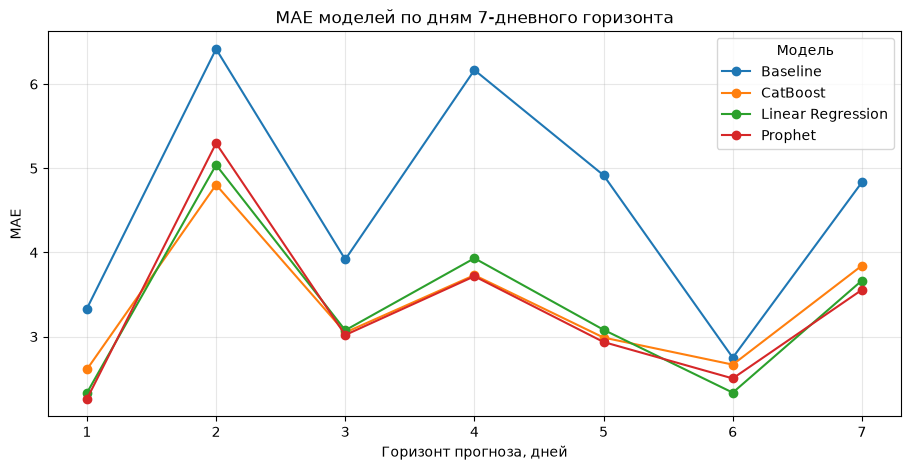

In [74]:
mae_by_horizon.plot(marker='o', figsize=(11, 5))
plt.xlabel('Горизонт прогноза, дней')
plt.ylabel('MAE')
plt.title('MAE моделей по дням 7-дневного горизонта')
plt.xticks(range(1, 8))
plt.grid(alpha=0.3)
plt.legend(title='Модель')
plt.show()


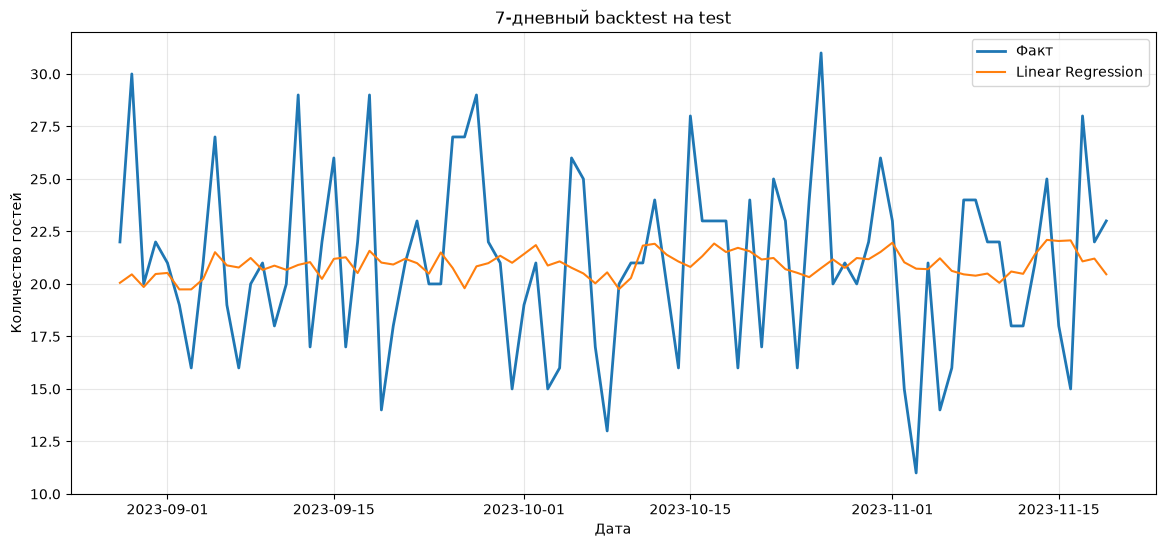

In [76]:
plt.figure(figsize=(14, 6))
plt.plot(test['date'], test[TARGET], label='Факт', linewidth=2)
plt.plot(linear_backtest['date'], linear_backtest['prediction'], label='Linear Regression')
plt.xlabel('Дата')
plt.ylabel('Количество гостей')
plt.title('7-дневный backtest на test')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Финальная оценка на validation

Лучшая модель выбирается только по test, после чего для неё выполняется такой же недельный backtest на ранее не использованном validation-периоде.


In [85]:
history_before_valid = pd.concat([train, test], ignore_index=True)

best_model_name = 'Linear Regression'

if best_model_name == 'Baseline':
    valid_backtest, valid_timing = weekly_backtest(
        history_before_valid, valid, baseline_forecast_7_days
    )
elif best_model_name == 'Linear Regression':
    valid_backtest, valid_timing = weekly_backtest(
        history_before_valid, valid, linear_forecast_7_days
    )
elif best_model_name == 'Prophet':
    valid_backtest, valid_timing = weekly_backtest(
        history_before_valid, valid, prophet_forecast_7_days
    )
else:
    valid_backtest, valid_timing = weekly_backtest(
        history_before_valid, valid, catboost_forecast_7_days
    )

final_mae_7d, final_mape_7d = calculate_metrics(valid_backtest)

print('Недельных запусков на validation:', len(valid_backtest) // 7)
print(f'Final {best_model_name} 7-day MAE: {final_mae_7d:.2f}')
print(f'Final {best_model_name} 7-day MAPE: {final_mape_7d:.2f}%')
print(f'Среднее время финального инференса недели: {valid_timing["inference_time_sec"].mean():.6f} сек.')


Недельных запусков на validation: 6
Final Linear Regression 7-day MAE: 3.26
Final Linear Regression 7-day MAPE: 16.18%
Среднее время финального инференса недели: 0.015539 сек.


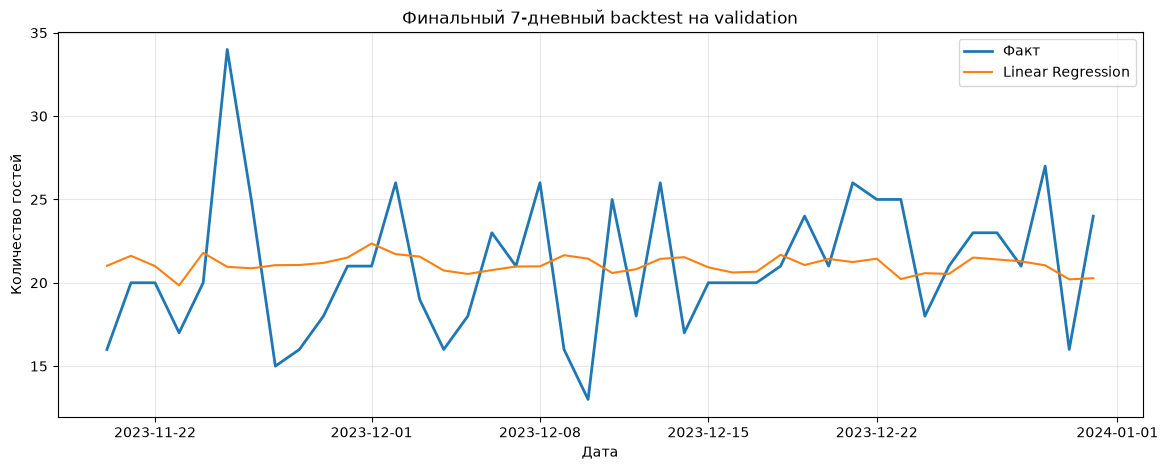

In [86]:
plt.figure(figsize=(14, 5))
plt.plot(valid_backtest['date'], valid_backtest['actual'], label='Факт', linewidth=2)
plt.plot(valid_backtest['date'], valid_backtest['prediction'], label=best_model_name)
plt.xlabel('Дата')
plt.ylabel('Количество гостей')
plt.title('Финальный 7-дневный backtest на validation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Прогноз на следующие 7 дней

После финальной оценки выбранная модель использует всю доступную историю и одним запуском строит прогноз на следующие семь календарных дней.

In [91]:
future_dates = pd.date_range(
    df['date'].max() + pd.Timedelta(days=1), periods=7, freq='D'
)

if best_model_name == 'Baseline':
    future_predictions, future_timing = baseline_forecast_7_days(
        df, future_dates
    )
elif best_model_name == 'Linear Regression':
    future_predictions, future_timing = linear_forecast_7_days(
        df, future_dates
    )
elif best_model_name == 'Prophet':
    future_predictions, future_timing = prophet_forecast_7_days(
        df, future_dates
    )
else:
    future_predictions, future_timing = catboost_forecast_7_days(
        df, future_dates
    )

future_forecast = pd.DataFrame({
    'date': future_dates,
    'prediction': future_predictions,
    'horizon': np.arange(1, 8),
})

print(f'Время инференса финального 7-дневного прогноза: {future_timing["inference_time_sec"]:.3f} сек.')
display(future_forecast)

Время инференса финального 7-дневного прогноза: 0.026 сек.


,date,prediction,horizon
0,2024-01-01,19.445973,1
1,2024-01-02,20.215423,2
2,2024-01-03,19.911744,3
3,2024-01-04,20.098326,4
4,2024-01-05,20.116691,5
5,2024-01-06,20.003398,6
6,2024-01-07,20.526254,7


In [ ]:
validation_horizon_metrics = calculate_horizon_metrics(
    valid_backtest,
    f'Final {best_model_name}',
)

print('Ошибка финальной модели по дням горизонта на validation')
display(validation_horizon_metrics.style.format({
    'MAE': '{:.1f}',
    'MAPE': '{:.1f}%',
}))


Ошибка финальной модели по дням горизонта на validation


,model,horizon,observations,MAE,MAPE
0,Final Linear Regression,1,6,4,21%
1,Final Linear Regression,2,6,3,15%
2,Final Linear Regression,3,6,2,10%
3,Final Linear Regression,4,6,2,11%
4,Final Linear Regression,5,6,3,13%
5,Final Linear Regression,6,6,5,23%
6,Final Linear Regression,7,6,4,21%


## Итог

Baseline, Linear Regression, Prophet и CatBoost оценены последовательно и в одинаковом сценарии недельного прогнозирования. Ни одна модель не использует фактические значения внутри прогнозируемой недели.
